In [ ]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.signal import welch

import utils_2Q_gate_zp as ut

In [5]:
print(1 - 10**(-2.36021921))
print(1 - 10**(-3.07601804))
print(1 - 10**(-3.03664572))

0.99563704443389
0.9991605748827784
0.9990809179590164


In [7]:
print(1 - 10**(-2.36021921))
print(1 - 10**(-5.0858031))
print(1 - 10**(-4.36594137))

0.99563704443389
0.9999917927644117
0.999956941526425


# First look at just the Pulse

In [17]:
buffer = 5
drive_amp = 1
drive_freq = 40
tg = 20
tlist = np.linspace(-buffer*tg, (buffer+1)*tg,  num=int(1000*tg))  # total time


## Gaussian Pulse, no DRAG

In [18]:
# For reference
# def drive_gauss_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     return A * (np.exp(-8 * t * (t - tg) / tg**2) - 1) * np.cos(wd * t) * (0<=t<=tg)

In [19]:
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': drive_freq,
            'gate_time': tg}
pulse = np.array([ut.drive_gauss_A(t, pulse_args) for t in tlist])

# Power spectrum of pulse
mag = np.fft.fftshift(np.abs(np.fft.fft(pulse)))
freqs = np.fft.fftshift(np.fft.fftfreq(pulse.size, tlist[1]-tlist[0]))
peak_loc = np.argmin(np.abs(freqs-drive_freq/(2*np.pi)))


In [20]:
ps_db = 20*np.log10(mag/mag[peak_loc])

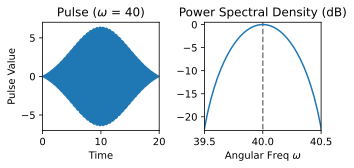

In [21]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(5, 2.5))
ax[0].plot(tlist, pulse)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 1, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs, ps_db)
delta = 0.5
xlim = [drive_freq - delta, drive_freq + delta]
ax[1].set_xlim(*xlim)
ax[1].set_ylim(np.min(ps_db[np.argmin(np.abs(2*np.pi*freqs-xlim[0])):peak_loc]),
               0.5+ps_db[peak_loc])
ax[0].set_title(f"Pulse ($\omega$ = {np.round(drive_freq, 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (dB)")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

### Checking vs analytic FT

We don't have exactly a Gaussian (+ numerics) so it should be close, but not exact. Our envelope equation is:

$$
V_G (t) = \exp[-\frac{8 t (t-t_g)}{t_g^2}] - 1 = \exp[-\frac{(t - t_g/2)^2}{2 (t_g/4)^2}]\cdot\exp[2] - 1.
$$

So it is a Gaussian with std $\sigma = t_g/4$, centered at $\mu = t_g/2$, multiplied by a constant factor $e^{2} \approx 7.4$. The $-1$ is so that $V_G(0) = V_G(t_g) = 0$, as

$$
\exp[-\frac{8 \cdot 0 \cdot (0-t_g)}{t_g^2}] = \exp[-\frac{8 t_g (t_g-t_g)}{t_g^2}] = 1.
$$

## With DRAG

For a DRAG pulse, we add an additional term:

$$
V(t) = V_G(t)\cos(\omega_d t) + \alpha V_G'(t)\sin(\omega_d t),
$$

with 

$$
V_G'(t) = \frac{d}{dt}V_G(t) = \frac{d}{dt}(\exp[-\frac{8 t (t-t_g)}{t_g^2}] - 1) = \frac{t_g - 2t}{t_g^2}\exp[-\frac{8 t (t-t_g)}{t_g^2}]
$$

This creates a notch filter in frequency at $w_{notch} = w_d-1/\alpha$. Let's try to place the notch on the previous pulse at $\omega = 3.2$

In [22]:
dt = tlist[1]-tlist[0]
delta = 0.2
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': drive_freq,
            'gate_time': tg,
            # 'dt': dt,
            'alpha_A': -1/delta
            }

In [23]:
# For reference in utils
# def drag_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     alpha = args.get('alpha_A', 0)
#     vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
#     return  vg* np.cos(wd* t)* (0<=t<=tg) + alpha* vg* (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=tg)
def drag_A(t: float, args: dict) -> float:
    A = args.get('drive_amp_A', 0)
    wd = args.get('drive_freq_A', 0)
    tg = args.get('gate_time', 0)
    alpha = args.get('alpha_A', 0)
    vg = A * (np.exp(-8 * t * (t - tg) / tg**2) - 1)
    # The + A in the second term is new
    return  vg* np.cos(wd* t)* (0<=t<=tg) + alpha* (vg + A) * (-8*(2*t-tg)/tg**2)* np.sin(wd* t)* (0<=t<=tg)

Look at the drag coefficient over time

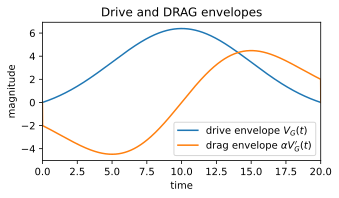

In [24]:
vg = drive_amp * (np.exp(-8 * tlist * (tlist - tg) / tg**2) - 1) * np.logical_and(0<=tlist, tlist<=tg)
drag_coeff = (-1/delta)* (vg + drive_amp) * (-8*(2*tlist-tg)/tg**2) * np.logical_and(0<=tlist, tlist<=tg)
f, ax = plt.subplots(ncols = 1, figsize=(5, 2.5))
plt.plot(tlist, vg*np.ones_like(tlist), label=r"drive envelope $V_G(t)$")
plt.plot(tlist, drag_coeff, label=r"drag envelope $\alpha V_G'(t)$")
plt.xlabel("time")
plt.ylabel("magnitude")
plt.xlim(0, tg)
plt.title("Drive and DRAG envelopes")
plt.legend();


In [25]:
print("pulse areas V_G:", np.sum(vg*dt), "DRAG", np.sum(drag_coeff*dt))

pulse areas V_G: 68.39439634353096 DRAG 2.4868995751603507e-14


It is worth noting that the drag envelope values are on the same order as the main drive envelope

Do the pulse

In [26]:
# pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])
pulse_drag = np.array([ut.drag_A(t, pulse_args) for t in tlist])

# Power spectrum of pulse
mag_drag = np.fft.fftshift(np.abs(np.fft.fft(pulse_drag)))
freqs_drag = np.fft.fftshift(np.fft.fftfreq(pulse_drag.size, tlist[1]-tlist[0]))
ps_db_drag = 20*np.log10(mag_drag/mag[peak_loc])


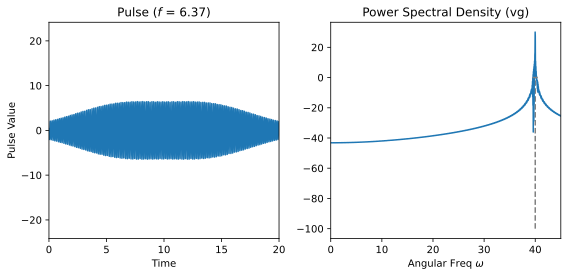

In [27]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse_drag)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 10, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs_drag, ps_db_drag)
delta = 0.5
xlim = [drive_freq - delta, drive_freq + delta]
xstart = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[0]))
xend = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[1]))
# ax[1].set_xlim(*xlim)
ax[1].hlines(0, xlim[0], xlim[1], colors = "gray", linestyles = "--")
ax[1].set_xlim(0,45)
ax[0].set_title(f"Pulse ($f$ = {np.round(drive_freq/(2*np.pi), 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (vg)")
# ax[1].set_title("Power Spectral Density (dB)\n0db is peak of pulse without drag")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

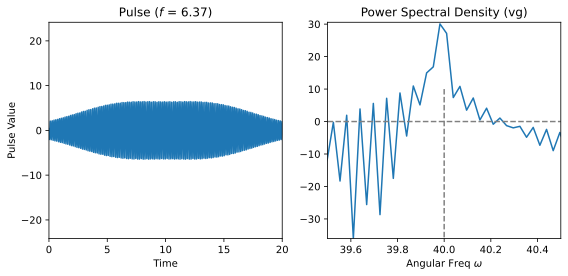

In [28]:
# Plot spectrum and pulse
f, ax = plt.subplots(ncols = 2, figsize=(8, 4))
ax[0].plot(tlist, pulse_drag)
ax[0].set_xlim(0, tg)
ax[1].vlines(drive_freq, -100, 10, colors = "gray", linestyles = "--")
ax[1].plot(2*np.pi*freqs_drag, ps_db_drag)
delta = 0.5
xlim = [drive_freq - delta, drive_freq + delta]
xstart = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[0]))
xend = np.argmin(np.abs(2*np.pi*freqs_drag-xlim[1]))
ax[1].set_xlim(*xlim)
ax[1].hlines(0, xlim[0], xlim[1], colors = "gray", linestyles = "--")
ax[1].set_ylim(np.min(ps_db_drag[xstart:xend]),
               0.5+np.max(ps_db_drag[xstart:xend]))
ax[0].set_title(f"Pulse ($f$ = {np.round(drive_freq/(2*np.pi), 2)})")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Pulse Value")
ax[1].set_title("Power Spectral Density (vg)")
# ax[1].set_title("Power Spectral Density (dB)\n0db is peak of pulse without drag")
ax[1].set_xlabel(r"Angular Freq $\omega$")
plt.tight_layout();

# Quantum Toy Model

First do Transmon-like

In [29]:
w01 = 3
w12 = 3.2
H0 = w01*qt.basis(3, 1).proj() + (w01+w12)*qt.basis(3, 2).proj()
H0

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0.  0.  0. ]
 [0.  3.  0. ]
 [0.  0.  6.2]]

In [30]:
H1 = qt.basis(3, 1)*qt.basis(3, 0).dag() + qt.basis(3, 2)*qt.basis(3, 1).dag()
H1 = H1 + H1.dag()
H1

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 1. 0.]
 [1. 0. 1.]
 [0. 1. 0.]]

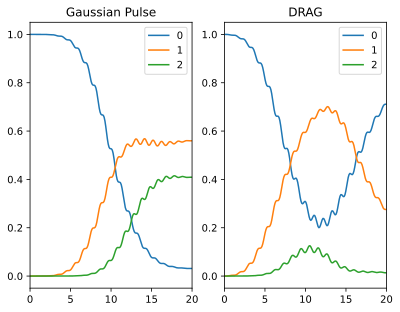

In [31]:
e_ops = [qt.basis(3,i).proj() for i in range(3)]
H_qbt_drive = [H0, [H1,ut.drive_gauss_A]]
H_qbt_drive_drag = [H0, [H1,drag_A]]
t_list = np.linspace(0, tg, 200)
delta = 0.2
# Drive amp to do a pi pulse if there were no third state np.pi/np.sum(vg*dt)
pulse_args = {'drive_amp_A': 0.0459,
            'drive_freq_A': w01,
            'gate_time': tg,
            'dt': dt,
            'alpha_A': -1/delta
            }
# Evolve state from 0 under the drive with and without drag
res = qt.sesolve(H=H_qbt_drive, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops)
res_drag = qt.sesolve(H=H_qbt_drive_drag, psi0 = qt.basis(3, 0), tlist=t_list, args=pulse_args, e_ops=e_ops)

f, ax = plt.subplots(ncols=2)

for i, expect in enumerate(res.expect):
    ax[0].plot(t_list, res.expect[i], label=i)
    ax[0].set_xlim(0, tg)
ax[0].legend()

for i, expect in enumerate(res_drag.expect):
    ax[1].plot(t_list, res_drag.expect[i], label=i)
    ax[1].set_xlim(0, tg)
ax[1].legend()

ax[0].set_title("Gaussian Pulse")
ax[1].set_title("DRAG");

Much less population enters the intermediate state using DRAG vs. not using DRAG

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

: 

# Old

In [ ]:
# def drive_gauss_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     return A * (np.exp(-8 * t * (t - tg) / tg**2)) * np.cos(wd * t)

# pulse_args = {'drive_amp_A': drive_amp,
#             'drive_freq_A': drive_freq,
#             'gate_time': tg}

# pulse = np.array([drive_gauss_A(t, pulse_args) for t in tlist])

In [ ]:
# def drag_A(t: float, args: dict) -> float:
#     A = args.get('drive_amp_A', 0)
#     wd = args.get('drive_freq_A', 0)
#     tg = args.get('gate_time', 0)
#     alpha = args.get('alpha_A', 0)
#     dt = args.get('alpha_A', 0.00001)
#     vg = lambda t_: A * (np.exp(-8 * t_ * (t_ - tg) / tg**2) - 1) * (0<=t_<=tg)
#     return  vg(t) * np.cos(wd * t) + alpha * (vg(t+dt/2) - vg(t-dt/2))/dt * np.sin(wd * t)

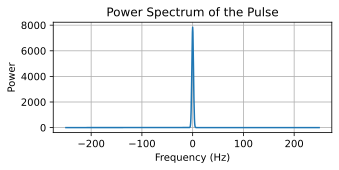

In [ ]:

# Step 1: Define the time-domain pulse
t = np.linspace(-1, 1, 1000)  # Time vector (s)
pulse = np.exp(-t**2 / 0.01)  # Example: Gaussian pulse

# Step 2: Compute the FFT
N = len(t)
dt = t[1] - t[0]  # Time step
freq = np.fft.fftfreq(N, dt)  # Frequency vector
fft_values = np.fft.fft(pulse)  # Compute FFT

# Step 3: Compute the power spectrum
power_spectrum = np.abs(fft_values)**2

# Step 4: Plot the results
plt.figure(figsize=(5, 2))
plt.plot(np.fft.fftshift(freq), np.fft.fftshift(power_spectrum))  # Shift zero freq to center
plt.title("Power Spectrum of the Pulse")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True)
plt.show()


In [ ]:
truc1 = 30
drive_phi, drive_theta, drag = False, True, 1
[H0, drive_term, w_trans_1, w_trans_2, hspace_charge] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc1,)
hilbert_space = [0,2,7,25]
amp_bounds, detune_bounds, alpha_bounds = [(0, 0.5), (-0.3, 0.3), (-20, 20)]
tg_vec = [20]
workers, popsize = 120, 20
recombination, tol, mutation = [0.7, 0.01, (0.5, 1.9)]
if drag == 0:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds)
else:
    bounds = (amp_bounds, amp_bounds, detune_bounds, detune_bounds, alpha_bounds)


In [ ]:

tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.418621, 0.093468, 0.169464, 0.171969, 0, 0]
# tg, drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B = [20, 0.374488, 0.170669, 0.240864, 0.1934, -1.264711, 0]

# H0, drive_term, w_trans_1, w_trans_2 = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc1)
n_cpu = 30
argz = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, tg,
        drive_amp_A, drive_amp_B, detune_A, detune_B, alpha_A, alpha_B]

fidel_alpha = ut.xgate_fidelity(argz)
# print('num of truncation =', truc2)
print('fidelity_alpha = ', fidel_alpha)

pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        'alpha_A': alpha_A }
tlist = np.linspace(0, tg,  num=int(500*tg))  # total time
pulse = np.array([ut.drag_A(t, pulse_args) for t in tlist])


drive_freq = w_trans_1 + 2*np.pi*detune_A
print('drive_freq=',drive_freq/(2*np.pi))

fidelity_alpha =  -2.989886462755471
drive_freq= 7.152173855261988


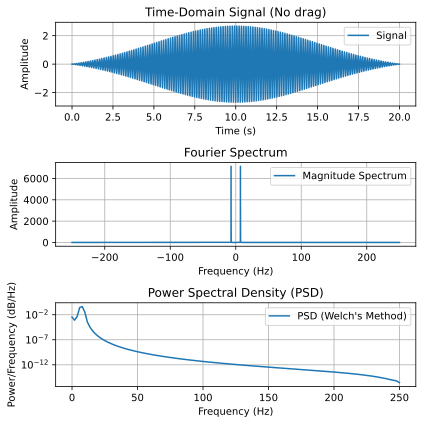

In [ ]:
signal = pulse
N = len(tlist) # Total number of samples
fs = 1/(tlist[1] - tlist[0])  # Time step
# Fourier Spectrum
fft_values = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency vector
magnitude_spectrum = np.abs(fft_values)  # Magnitude of the Fourier Transform
phase_spectrum = np.angle(fft_values)  # Phase of the Fourier Transform

# Power Spectral Density (PSD)
frequencies, psd = welch(signal, fs, nperseg=256)  # Welch's method

# Plotting
plt.figure(figsize=(6, 6))

# Time-domain signal
plt.subplot(3, 1, 1)
plt.plot(tlist, signal, label="Signal")
plt.title("Time-Domain Signal (No drag)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

# Fourier Spectrum
plt.subplot(3, 1, 2)
plt.plot(np.fft.fftshift(freqs), np.fft.fftshift(magnitude_spectrum), label="Magnitude Spectrum")
plt.title("Fourier Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

# Power Spectral Density
plt.subplot(3, 1, 3)
plt.semilogy(frequencies, psd, label="PSD (Welch's Method)")
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


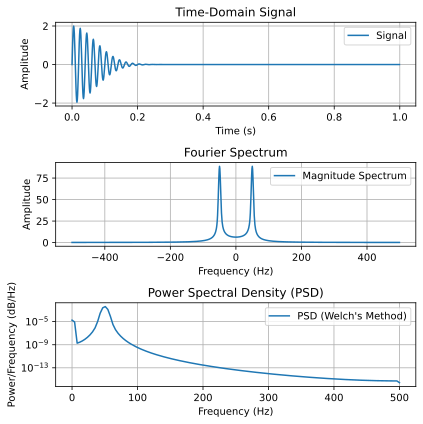

In [ ]:

# Parameters
fs = 1000  # Sampling frequency (Hz)
T = 1      # Signal duration (s)
N = T * fs  # Total number of samples
t = np.linspace(0, T, N, endpoint=False)  # Time vector

# Generate a sinusoidal signal
f0 = 50  # Signal frequency (Hz)
A = 2    # Amplitude
signal = A * np.sin(2 * np.pi * f0 * t) *np.exp(-t**2 / 0.01)
# signal = A * np.sin(2 * np.pi * f0 * t)

# Fourier Spectrum
fft_values = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, 1/fs)  # Frequency vector
magnitude_spectrum = np.abs(fft_values)  # Magnitude of the Fourier Transform
phase_spectrum = np.angle(fft_values)  # Phase of the Fourier Transform

# Power Spectral Density (PSD)
frequencies, psd = welch(signal, fs, nperseg=256)  # Welch's method

# Plotting
plt.figure(figsize=(6, 6))

# Time-domain signal
plt.subplot(3, 1, 1)
plt.plot(t, signal, label="Signal")
plt.title("Time-Domain Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

# Fourier Spectrum
plt.subplot(3, 1, 2)
plt.plot(np.fft.fftshift(freqs), np.fft.fftshift(magnitude_spectrum), label="Magnitude Spectrum")
plt.title("Fourier Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()

# Power Spectral Density
plt.subplot(3, 1, 3)
plt.semilogy(frequencies, psd, label="PSD (Welch's Method)")
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


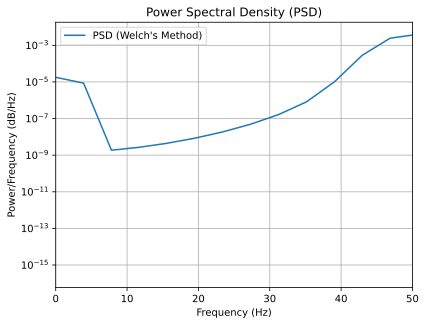

In [ ]:
plt.semilogy(frequencies, psd, label="PSD (Welch's Method)")
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlim(0, 50)
plt.grid()
plt.legend()